# Phase 2 Part 2 — Multi-Agent Q-Learning Coordination

This notebook implements the **tabular Q-learning** solution for the rover-and-lake coordination task.

The implementation follows the assignment constraints:

- 5×5 grid.
- Type A travels **X → U → X**.
- Type B travels **Y → V → Y**.
- Five actions: north, south, west, east, and wait.
- Each rover observes only its own position, carrying status, and lake state.
- Both actions are selected before either rover moves.
- Rewards are resolved before the lake may flip.
- No RL library or pre-trained model is used.

The code is deliberately split into small functions and classes so it remains easy to explain during the interview.


## Assumptions used in the simulation

The written task does not enumerate exact coordinates, so the four fixed locations are placed so the two shortest routes intersect at the centre:

- `X = (2, 0)`, `U = (2, 4)`
- `Y = (0, 2)`, `V = (4, 2)`
- `LAKE = (2, 2)`

The collision penalty is set to **−40** instead of the suggested −20. This is still a direct consequence-based penalty, not a rule telling either rover when to cross.

Training is staged, which the assignment explicitly allows. Type A learns first. Type B then learns against Type A's deployed greedy policy. A random 0–8 step launch offset is used before Type B training episodes to represent the scenario's **random rover launch times / continuous traffic**, without giving Type B access to Type A's location.


In [1]:

from dataclasses import dataclass
from enum import IntEnum
from typing import NamedTuple

import matplotlib.pyplot as plt
import numpy as np

GRID_SIZE = 5
ACTION_COUNT = 5
BINARY_STATE_COUNT = 2
Q_SHAPE = (
    GRID_SIZE,
    GRID_SIZE,
    BINARY_STATE_COUNT,
    BINARY_STATE_COUNT,
    ACTION_COUNT,
)

STEP_REWARD = -5.0
WAIT_REWARD = -3.0
COLLISION_REWARD = -40.0
WATER_REWARD = -20.0
SAMPLE_REWARD = 10.0
DELIVERY_REWARD = 50.0

X = (2, 0)
U = (2, 4)
Y = (0, 2)
V = (4, 2)
LAKE = (2, 2)

SEED = 42
EVALUATION_SEED = 2026
TYPE_A_EPISODES = 10_000
TYPE_B_EPISODES = 20_000
EVALUATION_EPISODES = 500
MAX_LAUNCH_OFFSET = 8
MIN_DECAY_STEPS = 1
SMOOTHING_WINDOW = 200
PLOT_SIZE = (9, 4)
EVALUATION_COUNTER_COUNT = 6

Position = tuple[int, int]
StateIndex = tuple[int, int, int, int]
QTable = np.ndarray
Rng = np.random.Generator
Rewards = tuple[float, float]


class Direction(IntEnum):
    NORTH = 0
    SOUTH = 1
    WEST = 2
    EAST = 3
    WAIT = 4


class RoverType(IntEnum):
    A = 0
    B = 1


@dataclass(frozen=True)
class RoverState:
    position: Position
    has_sample: bool
    deliveries: int = 0


@dataclass(frozen=True)
class WorldState:
    rover_a: RoverState
    rover_b: RoverState
    is_flooded: bool


@dataclass(frozen=True)
class JointAction:
    action_a: Direction
    action_b: Direction


@dataclass(frozen=True)
class LearningConfig:
    alpha: float = 0.15
    gamma: float = 0.99
    epsilon_start: float = 1.0
    epsilon_min: float = 0.02
    decay_fraction: float = 0.70


@dataclass(frozen=True)
class EnvironmentConfig:
    flip_probability: float = 0.10
    max_steps: int = 35


@dataclass(frozen=True)
class StageConfig:
    rover_type: RoverType
    episodes: int


@dataclass(frozen=True)
class Transition:
    state: StateIndex
    action: Direction
    reward: float
    next_state: StateIndex


@dataclass(frozen=True)
class TrainingRecord:
    before: WorldState
    result: "StepResult"
    actions: JointAction


class Safety(NamedTuple):
    has_collision: bool
    has_water_violation: bool


class StepResult(NamedTuple):
    world: WorldState
    reward_a: float
    reward_b: float
    safety: Safety


class EvaluationResult(NamedTuple):
    deliveries_a: int
    deliveries_b: int
    collisions: int
    water_violations: int
    a_dry_entries: int
    a_flooded_entries: int
    b_dry_entries: int
    b_flooded_entries: int


MOVE_DELTAS: dict[Direction, Position] = {
    Direction.NORTH: (-1, 0),
    Direction.SOUTH: (1, 0),
    Direction.WEST: (0, -1),
    Direction.EAST: (0, 1),
    Direction.WAIT: (0, 0),
}

## State, actions, rewards and Q-table

For each rover, the observable state is:

`(row, column, has_sample, is_flooded)`

The Q-table therefore has shape:

`(5, 5, 2, 2, 5)`

The standard update is:

\[
Q(s,a) \leftarrow Q(s,a) + \alpha
\left[r + \gamma \max_{a'} Q(s',a') - Q(s,a)\right]
\]

No desired crossing policy is hard-coded. The coordination behavior must emerge from movement cost, waiting cost, water damage, collisions, pickup reward and delivery reward.


In [2]:
def clamp(value: int) -> int:
    return max(0, min(GRID_SIZE - 1, value))


def move(position: Position, action: Direction) -> Position:
    delta = MOVE_DELTAS[action]
    row = clamp(position[0] + delta[0])
    column = clamp(position[1] + delta[1])
    return row, column


def get_base(rover_type: RoverType) -> Position:
    if rover_type == RoverType.A:
        return X
    return Y


def get_goal(rover_type: RoverType) -> Position:
    if rover_type == RoverType.A:
        return U
    return V


def reaches_goal(rover: RoverState, rover_type: RoverType) -> bool:
    is_goal = rover.position == get_goal(rover_type)
    is_empty = rover.has_sample is False
    checks = (is_goal, is_empty)
    return all(checks)


def reaches_base(rover: RoverState, rover_type: RoverType) -> bool:
    checks = (rover.position == get_base(rover_type), rover.has_sample)
    return all(checks)


def apply_mission_event(rover: RoverState,
                        rover_type: RoverType) -> RoverState:
    if reaches_goal(rover, rover_type):
        return RoverState(rover.position, True, rover.deliveries)
    if reaches_base(rover, rover_type):
        return RoverState(rover.position, False, rover.deliveries + 1)
    return rover


def get_action_reward(action: Direction) -> float:
    if action == Direction.WAIT:
        return WAIT_REWARD
    return STEP_REWARD


def get_event_reward(before: RoverState, after: RoverState) -> float:
    if after.deliveries > before.deliveries:
        return DELIVERY_REWARD
    has_changed_load = after.has_sample != before.has_sample
    if has_changed_load:
        return SAMPLE_REWARD
    return 0.0


def is_collision(position_a: Position, position_b: Position) -> bool:
    return all((position_a == position_b, position_a == LAKE))


def is_water_violation(position: Position, is_flooded: bool) -> bool:
    return all((position == LAKE, is_flooded))


def encode_state(rover: RoverState, is_flooded: bool) -> StateIndex:
    row, column = rover.position
    return row, column, int(rover.has_sample), int(is_flooded)


def create_rover(rover_type: RoverType) -> RoverState:
    return RoverState(get_base(rover_type), False)


def create_world(is_flooded: bool) -> WorldState:
    rover_a = create_rover(RoverType.A)
    rover_b = create_rover(RoverType.B)
    return WorldState(rover_a, rover_b, is_flooded)


def add_safety(rewards: Rewards, safety: Safety) -> Rewards:
    reward_a = rewards[0] + COLLISION_REWARD * int(safety.has_collision)
    reward_a += WATER_REWARD * int(safety.has_water_violation)
    reward_b = rewards[1] + COLLISION_REWARD * int(safety.has_collision)
    return reward_a, reward_b

## Environment

`GridEnvironment.step()` implements the required simultaneous-step order:

1. Both rover actions are already chosen.
2. Both rovers move.
3. Collision and water consequences are calculated using the **current** lake state.
4. Pickup/drop-off events and rewards are applied.
5. Only then may the lake flip.


In [3]:
class GridEnvironment:
    """Simultaneous 5x5 rover environment."""

    def __init__(self, config: EnvironmentConfig, rng: Rng) -> None:
        self.config = config
        self.rng = rng

    def reset(self) -> WorldState:
        return create_world(bool(self.rng.integers(BINARY_STATE_COUNT)))

    def move_rover(self, rover: RoverState, action: Direction) -> RoverState:
        position = move(rover.position, action)
        return RoverState(position, rover.has_sample, rover.deliveries)

    def get_safety(self, a: RoverState, b: RoverState,
                   world: WorldState) -> Safety:
        has_collision = is_collision(a.position, b.position)
        has_water = is_water_violation(a.position, world.is_flooded)
        return Safety(has_collision, has_water)

    def get_base_rewards(self, actions: JointAction) -> Rewards:
        reward_a = get_action_reward(actions.action_a)
        reward_b = get_action_reward(actions.action_b)
        return reward_a, reward_b

    def apply_events(self, a: RoverState,
                     b: RoverState) -> tuple[RoverState, RoverState]:
        after_a = apply_mission_event(a, RoverType.A)
        after_b = apply_mission_event(b, RoverType.B)
        return after_a, after_b

    def add_events(self, world: WorldState, rovers: tuple[RoverState,
                   RoverState], rewards: Rewards) -> Rewards:
        reward_a = rewards[0] + get_event_reward(world.rover_a, rovers[0])
        reward_b = rewards[1] + get_event_reward(world.rover_b, rovers[1])
        return reward_a, reward_b

    def flip_lake(self, is_flooded: bool) -> bool:
        should_flip = self.rng.random() < self.config.flip_probability
        if should_flip:
            return not is_flooded
        return is_flooded

    def get_moved(self, world: WorldState,
                  actions: JointAction) -> tuple[RoverState, RoverState]:
        rover_a = self.move_rover(world.rover_a, actions.action_a)
        rover_b = self.move_rover(world.rover_b, actions.action_b)
        return rover_a, rover_b

    def step(self, world: WorldState, actions: JointAction) -> StepResult:
        moved = self.get_moved(world, actions)
        safety = self.get_safety(*moved, world)
        rewards = add_safety(self.get_base_rewards(actions), safety)
        rovers = self.apply_events(*moved)
        rewards = self.add_events(world, rovers, rewards)
        flooded = self.flip_lake(world.is_flooded)
        return StepResult(WorldState(*rovers, flooded), *rewards, safety)

## Q-learning and staged training

Two separate Q-tables are used because the rover types have different destinations and different water vulnerability.

- **Stage A:** Type A learns while Type B remains at its base.
- **Stage B:** Type A follows its learned greedy policy; Type B learns with ε-greedy exploration.
- The random launch offset in Stage B makes Type B encounter Type A at different phases of its route.

This keeps the agents' observations unchanged: neither rover is ever given the other rover's position.


In [4]:
class QLearner:
    """Tabular Q-learning agent."""

    def __init__(self, config: LearningConfig, rng: Rng) -> None:
        self.config = config
        self.rng = rng
        self.q_table = np.zeros(Q_SHAPE, dtype=np.float64)

    def choose_greedy(self, state: StateIndex) -> Direction:
        return Direction(int(np.argmax(self.q_table[state])))

    def choose(self, state: StateIndex, epsilon: float) -> Direction:
        is_exploring = self.rng.random() < epsilon
        if is_exploring:
            return Direction(int(self.rng.integers(ACTION_COUNT)))
        return self.choose_greedy(state)

    def get_new_value(self, old_value: float, target: float) -> float:
        difference = target - old_value
        return old_value + self.config.alpha * difference

    def update(self, transition: Transition) -> None:
        index = transition.state + (int(transition.action),)
        old_value = self.q_table[index]
        best_next = float(np.max(self.q_table[transition.next_state]))
        target = transition.reward + self.config.gamma * best_next
        self.q_table[index] = self.get_new_value(old_value, target)


def get_epsilon(episode: int, total: int,
                config: LearningConfig) -> float:
    decay_steps = max(MIN_DECAY_STEPS, int(total * config.decay_fraction))
    progress = min(1.0, episode / decay_steps)
    span = config.epsilon_start - config.epsilon_min
    return config.epsilon_start - span * progress


def is_complete(world: WorldState) -> bool:
    checks = (world.rover_a.deliveries > 0, world.rover_b.deliveries > 0)
    return all(checks)

In [5]:
class StageTrainer:
    """Train A, then train B against A's greedy policy."""

    def __init__(self, env: GridEnvironment, a: QLearner,
                 b: QLearner) -> None:
        self.env = env
        self.a = a
        self.b = b

    def select_a(self, state: StateIndex, epsilon: float,
                 stage: RoverType) -> Direction:
        is_training_a = stage == RoverType.A
        if is_training_a:
            return self.a.choose(state, epsilon)
        return self.a.choose_greedy(state)

    def select_b(self, state: StateIndex, epsilon: float,
                 stage: RoverType) -> Direction:
        is_training_a = stage == RoverType.A
        if is_training_a:
            return Direction.WAIT
        return self.b.choose(state, epsilon)

    def select_actions(self, world: WorldState, epsilon: float,
                       stage: RoverType) -> JointAction:
        state_a = encode_state(world.rover_a, world.is_flooded)
        state_b = encode_state(world.rover_b, world.is_flooded)
        action_a = self.select_a(state_a, epsilon, stage)
        action_b = self.select_b(state_b, epsilon, stage)
        return JointAction(action_a, action_b)

    def make_transition(self, record: TrainingRecord,
                        rover_type: RoverType) -> Transition:
        is_type_a = rover_type == RoverType.A
        if is_type_a:
            return self.make_a_transition(record)
        return self.make_b_transition(record)

    def make_a_transition(self, record: TrainingRecord) -> Transition:
        state = encode_state(record.before.rover_a, record.before.is_flooded)
        after = record.result.world
        next_state = encode_state(after.rover_a, after.is_flooded)
        return Transition(state, record.actions.action_a,
                          record.result.reward_a, next_state)

    def make_b_transition(self, record: TrainingRecord) -> Transition:
        state = encode_state(record.before.rover_b, record.before.is_flooded)
        after = record.result.world
        next_state = encode_state(after.rover_b, after.is_flooded)
        return Transition(state, record.actions.action_b,
                          record.result.reward_b, next_state)

    def learn(self, record: TrainingRecord, stage: RoverType) -> None:
        transition = self.make_transition(record, stage)
        is_training_a = stage == RoverType.A
        if is_training_a:
            self.a.update(transition)
            return
        self.b.update(transition)

    def run_step(self, world: WorldState, epsilon: float,
                 stage: RoverType) -> tuple[WorldState, float]:
        actions = self.select_actions(world, epsilon, stage)
        result = self.env.step(world, actions)
        self.learn(TrainingRecord(world, result, actions), stage)
        return result.world, result.reward_a + result.reward_b

    def advance_a(self, world: WorldState, steps: int) -> WorldState:
        for _ in range(steps):
            state = encode_state(world.rover_a, world.is_flooded)
            action = self.a.choose_greedy(state)
            world = self.env.step(
                world, JointAction(action, Direction.WAIT)
            ).world
        return world

    def prepare_world(self, stage: RoverType) -> WorldState:
        world = self.env.reset()
        is_training_a = stage == RoverType.A
        if is_training_a:
            return world
        steps = int(self.env.rng.integers(MAX_LAUNCH_OFFSET + 1))
        return self.advance_a(world, steps)

    def run_episode(self, epsilon: float, stage: RoverType) -> float:
        world, total = self.prepare_world(stage), 0.0
        for _ in range(self.env.config.max_steps):
            world, reward = self.run_step(world, epsilon, stage)
            total += reward
            if is_complete(world):
                break
        return total

    def train(self, stage: StageConfig) -> np.ndarray:
        rewards = np.zeros(stage.episodes, dtype=np.float64)
        for episode in range(stage.episodes):
            epsilon = get_epsilon(episode, stage.episodes, self.a.config)
            rewards[episode] = self.run_episode(epsilon, stage.rover_type)
        return rewards


def entered_lake(before: Position, after: Position) -> bool:
    return all((before != LAKE, after == LAKE))


def split_entry(has_entry: bool, is_flooded: bool) -> tuple[int, int]:
    count = int(has_entry)
    flooded = count * int(is_flooded)
    return count - flooded, flooded



def create_counters() -> np.ndarray:
    return np.zeros(EVALUATION_COUNTER_COUNT, dtype=np.int64)


def get_entry_pair(before: Position, after: Position,
                   is_flooded: bool) -> tuple[int, int]:
    has_entry = entered_lake(before, after)
    return split_entry(has_entry, is_flooded)

## Sanity checks

These checks target the most error-prone environment rules: flooded entry, reward-before-lake-flip timing, and simultaneous collision detection.


In [6]:

def make_test_env(flip_probability: float) -> GridEnvironment:
    config = EnvironmentConfig(flip_probability=flip_probability, max_steps=5)
    rng = np.random.default_rng(SEED)
    return GridEnvironment(config, rng)


def test_flooded_entry() -> None:
    env = make_test_env(0.0)
    rover_a = RoverState((2, 1), False)
    world = WorldState(rover_a, create_rover(RoverType.B), True)
    actions = JointAction(Direction.EAST, Direction.WAIT)
    result = env.step(world, actions)
    assert result.safety.has_water_violation


def test_dry_entry_before_flip() -> None:
    env = make_test_env(1.0)
    rover_a = RoverState((2, 1), False)
    world = WorldState(rover_a, create_rover(RoverType.B), False)
    actions = JointAction(Direction.EAST, Direction.WAIT)
    result = env.step(world, actions)
    assert result.safety.has_water_violation is False


def test_simultaneous_collision() -> None:
    env = make_test_env(0.0)
    rover_a = RoverState((2, 1), False)
    rover_b = RoverState((1, 2), False)
    world = WorldState(rover_a, rover_b, False)
    actions = JointAction(Direction.EAST, Direction.SOUTH)
    result = env.step(world, actions)
    assert result.safety.has_collision


def run_sanity_checks() -> None:
    test_flooded_entry()
    test_dry_entry_before_flip()
    test_simultaneous_collision()
    print("Sanity checks passed.")


run_sanity_checks()


Sanity checks passed.


## Train

The default configuration uses `γ = 0.99`, because the task requires agents to value future delivery rewards enough to wait for a safer crossing opportunity.


In [7]:
training_rng = np.random.default_rng(SEED)
training_env = GridEnvironment(EnvironmentConfig(), training_rng)
learning_config = LearningConfig()

learner_a = QLearner(learning_config, training_rng)
learner_b = QLearner(learning_config, training_rng)
trainer = StageTrainer(training_env, learner_a, learner_b)

stage_a = StageConfig(RoverType.A, TYPE_A_EPISODES)
stage_b = StageConfig(RoverType.B, TYPE_B_EPISODES)

rewards_a = trainer.train(stage_a)
rewards_b = trainer.train(stage_b)

print("Stage A episodes:", len(rewards_a))
print("Stage B episodes:", len(rewards_b))


Stage A episodes: 10000
Stage B episodes: 20000


## Greedy evaluation

Evaluation uses the learned greedy policies (`ε = 0`). The important evidence is:

- Type A flooded entries should be 0.
- Type B dry entries should be 0.
- A/B lake collisions should be 0.
- Type A water violations should be 0.
- Both rover types should keep completing deliveries.


In [8]:
class Evaluator:
    """Evaluate both learned policies with epsilon equal to zero."""

    def __init__(self, env: GridEnvironment, a: QLearner,
                 b: QLearner) -> None:
        self.env = env
        self.a = a
        self.b = b

    def get_actions(self, world: WorldState) -> JointAction:
        state_a = encode_state(world.rover_a, world.is_flooded)
        state_b = encode_state(world.rover_b, world.is_flooded)
        action_a = self.a.choose_greedy(state_a)
        action_b = self.b.choose_greedy(state_b)
        return JointAction(action_a, action_b)

    def get_entries(self, before: WorldState,
                    after: WorldState) -> tuple[int, int, int, int]:
        a_before, a_after = before.rover_a.position, after.rover_a.position
        b_before, b_after = before.rover_b.position, after.rover_b.position
        pair_a = get_entry_pair(a_before, a_after, before.is_flooded)
        pair_b = get_entry_pair(b_before, b_after, before.is_flooded)
        return *pair_a, *pair_b

    def run_step(self, world: WorldState,
                 totals: np.ndarray) -> tuple[WorldState, np.ndarray]:
        result = self.env.step(world, self.get_actions(world))
        entries = self.get_entries(world, result.world)
        safety = result.safety
        additions = np.asarray((safety.has_collision,
                                safety.has_water_violation, *entries))
        return result.world, totals + additions

    def build_result(self, world: WorldState,
                     totals: np.ndarray) -> EvaluationResult:
        metrics = [int(value) for value in totals]
        return EvaluationResult(world.rover_a.deliveries,
                                world.rover_b.deliveries, *metrics)

    def run_episode(self) -> EvaluationResult:
        world, totals = self.env.reset(), create_counters()
        for _ in range(self.env.config.max_steps):
            world, totals = self.run_step(world, totals)
            if is_complete(world):
                break
        return self.build_result(world, totals)

    def evaluate(self, episodes: int) -> EvaluationResult:
        results = [self.run_episode() for _ in range(episodes)]
        values = np.sum(np.asarray(results, dtype=np.int64), axis=0)
        return EvaluationResult(*[int(value) for value in values])

In [9]:
def moving_average(values: np.ndarray, window: int) -> np.ndarray:
    size = min(window, len(values))
    kernel = np.ones(size, dtype=np.float64) / size
    return np.convolve(values, kernel, mode="valid")


def plot_stage(values: np.ndarray, title: str) -> None:
    plt.figure(figsize=PLOT_SIZE)
    plt.plot(moving_average(values, SMOOTHING_WINDOW))
    plt.xlabel("Episode")
    plt.ylabel("Smoothed total reward")
    plt.title(title)
    plt.show()


def print_evaluation(result: EvaluationResult) -> None:
    print(f"Type A deliveries: {result.deliveries_a}")
    print(f"Type B deliveries: {result.deliveries_b}")
    print(f"Lake collisions: {result.collisions}")
    print(f"Type A water violations: {result.water_violations}")
    print("A entries (dry/flood):", result.a_dry_entries,
          result.a_flooded_entries)
    print("B entries:", result.b_dry_entries, result.b_flooded_entries)

In [10]:
evaluation_rng = np.random.default_rng(EVALUATION_SEED)
evaluation_env = GridEnvironment(EnvironmentConfig(), evaluation_rng)
evaluator = Evaluator(evaluation_env, learner_a, learner_b)

evaluation = evaluator.evaluate(EVALUATION_EPISODES)
print_evaluation(evaluation)


Type A deliveries: 500
Type B deliveries: 500
Lake collisions: 0
Type A water violations: 0
A entries (dry/flood): 673 0
B entries: 0 703


## Training curves

The moving average is only for visualization; it does not affect learning.


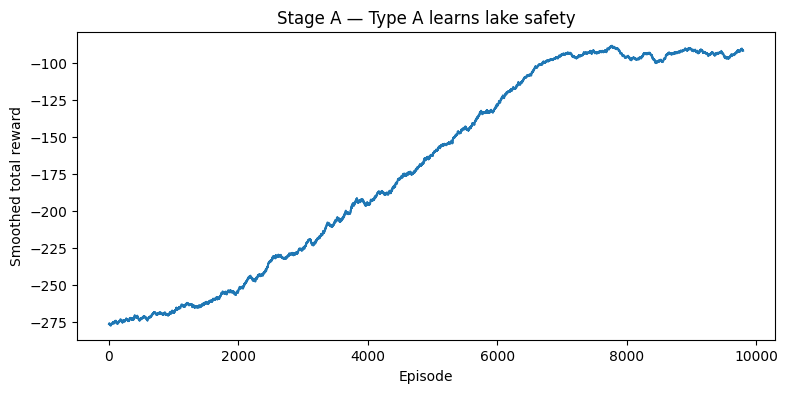

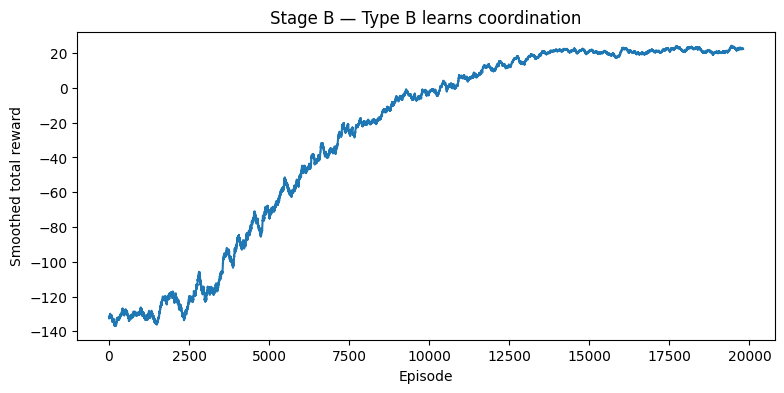

In [11]:
plot_stage(rewards_a, "Stage A — Type A learns lake safety")
plot_stage(rewards_b, "Stage B — Type B learns coordination")


## Interpretation

A successful run should show the intended coordination convention:

- **Dry lake:** Type A uses the central crossing; Type B yields.
- **Flooded lake:** Type A avoids the lake; Type B uses the crossing.

The lake state therefore acts as an implicit shared coordination signal even though the agents cannot directly observe one another.


## FINAL ANIMATION — Learned Multi-Agent Coordination

In [12]:
from matplotlib import animation
from matplotlib.axes import Axes

ANIMATION_SEED = 2027
ANIMATION_STEPS = 50
ANIMATION_INTERVAL_MS = 450
ANIMATION_FIGSIZE = (7, 7)

TYPE_A_COLOR = "tab:red"
TYPE_B_COLOR = "tab:blue"
LAKE_COLOR = "deepskyblue"

DRY_LAKE_ALPHA = 0.18
FLOODED_LAKE_ALPHA = 0.70

SITE_LABELS: dict[str, Position] = {
    "X": X,
    "U": U,
    "Y": Y,
    "V": V,
}


def collect_states(env: GridEnvironment, policy: Evaluator,
                   steps: int) -> list[WorldState]:
    world = env.reset()
    states = [world]
    for _ in range(steps):
        world = env.step(world, policy.get_actions(world)).world
        states.append(world)
    return states


def configure_axis(ax: Axes) -> None:
    ax.set_xlim(-0.5, GRID_SIZE - 0.5)
    ax.set_ylim(GRID_SIZE - 0.5, -0.5)
    ax.set_xticks(np.arange(-0.5, GRID_SIZE, 1))
    ax.set_yticks(np.arange(-0.5, GRID_SIZE, 1))
    ax.grid(True, linewidth=1.2)
    ax.tick_params(labelbottom=False, labelleft=False, length=0)
    ax.set_aspect("equal")


def draw_sites(ax: Axes) -> None:
    for label, position in SITE_LABELS.items():
        row, column = position
        ax.text(column, row, label, ha="center", va="center",
                fontsize=16, fontweight="bold", alpha=0.40)


def draw_lake(ax: Axes, is_flooded: bool) -> None:
    row, column = LAKE
    alpha = FLOODED_LAKE_ALPHA if is_flooded else DRY_LAKE_ALPHA
    label = "FLOODED" if is_flooded else "DRY"
    ax.scatter(column, row, s=2800, marker="s",
               color=LAKE_COLOR, alpha=alpha)
    ax.text(column, row, label, ha="center", va="center",
            fontweight="bold")


def draw_rover(ax: Axes, rover: RoverState, name: str,
               rover_color: str) -> None:
    row, column = rover.position
    sample = "*" if rover.has_sample else ""
    ax.scatter(column, row, s=600, color=rover_color, zorder=3)
    ax.text(column, row, f"{name}{sample}", ha="center",
            va="center", color="white", fontweight="bold")


def draw_rovers(ax: Axes, world: WorldState) -> None:
    draw_rover(ax, world.rover_a, "A", TYPE_A_COLOR)
    draw_rover(ax, world.rover_b, "B", TYPE_B_COLOR)


def get_frame_title(world: WorldState, step: int) -> str:
    lake = "FLOODED" if world.is_flooded else "DRY"
    deliveries = (
        f"A={world.rover_a.deliveries}, B={world.rover_b.deliveries}"
    )
    return f"Step {step} | Lake: {lake} | Deliveries: {deliveries}"


def draw_frame(frame: int, states: list[WorldState],
               ax: Axes) -> None:
    world = states[frame]
    ax.clear()
    configure_axis(ax)
    draw_sites(ax)
    draw_lake(ax, world.is_flooded)
    draw_rovers(ax, world)
    ax.set_title(get_frame_title(world, frame))



# A fresh environment only for the animation.

animation_rng = np.random.default_rng(ANIMATION_SEED)

animation_env = GridEnvironment(
    EnvironmentConfig(),
    animation_rng,
)

animation_policy = Evaluator(
    animation_env,
    learner_a,
    learner_b,
)

animation_states = collect_states(
    animation_env,
    animation_policy,
    ANIMATION_STEPS,
)


plt.rcParams["animation.html"] = "jshtml"

figure, axis = plt.subplots(figsize=ANIMATION_FIGSIZE)

coordination_animation = animation.FuncAnimation(
    figure,
    draw_frame,
    frames=len(animation_states),
    fargs=(animation_states, axis),
    interval=ANIMATION_INTERVAL_MS,
    repeat=True,
)

plt.close(figure)

coordination_animation